This step loads the social media dataset and performs an initial inspection.

It helps understand the structure, data types, and size of the dataset.
This information guides the choice of preprocessing techniques.


In [ ]:
import pandas as pd
import numpy as np

# Load the social media dataset
df = pd.read_csv("/content/Students Social Media Addiction.csv")

# Display first few records
df.head()


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [ ]:
df.shape



(705, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null    int64  
dtypes: fl

Dataset structure analysis identifies the number of rows and columns.

It also shows the data types of attributes and presence of null values.
This helps separate numerical and categorical features.


In [ ]:
df.isnull().sum()


,0
Student_ID,0
Age,0
Gender,0
Academic_Level,0
Country,0
Avg_Daily_Usage_Hours,0
Most_Used_Platform,0
Affects_Academic_Performance,0
Sleep_Hours_Per_Night,0
Mental_Health_Score,0


Missing values reduce data quality and affect algorithm performance.

They must be identified before applying cleaning techniques.
This step checks for null values in each attribute.


In [ ]:
# Randomly introduce missing values across numeric columns
np.random.seed(42)

numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    df.loc[df.sample(frac=0.05).index, col] = np.nan  # 5% missing per column

df.isnull().sum()


,0
Student_ID,70
Age,70
Gender,0
Academic_Level,0
Country,0
Avg_Daily_Usage_Hours,35
Most_Used_Platform,0
Affects_Academic_Performance,0
Sleep_Hours_Per_Night,35
Mental_Health_Score,35


In [ ]:
# Fill missing values in numeric columns using mean
df[df.select_dtypes(include=[np.number]).columns] = (
    df.select_dtypes(include=[np.number]).fillna(
        df.select_dtypes(include=[np.number]).mean()
    )
)

# Verify missing values after imputation
df.isnull().sum()


,0
Student_ID,0
Age,0
Gender,0
Academic_Level,0
Country,0
Avg_Daily_Usage_Hours,0
Most_Used_Platform,0
Affects_Academic_Performance,0
Sleep_Hours_Per_Night,0
Mental_Health_Score,0


In [ ]:
# Check range of Addicted_Score
df['Addicted_Score'].min(), df['Addicted_Score'].max()

# Correct binning based on actual scale
addiction_bins = [0, 3, 6, 10]
addiction_labels = ['Low', 'Medium', 'High']

df['Addiction_Level'] = pd.cut(df['Addicted_Score'],
                               bins=addiction_bins,
                               labels=addiction_labels,
                               include_lowest=True)

df[['Addicted_Score', 'Addiction_Level']].head()


,Addicted_Score,Addiction_Level
0,6.440299,High
1,3.000000,Low
2,9.000000,High
3,4.000000,Medium
4,7.000000,High


In [ ]:
# Select numeric columns only
numeric_df = df.select_dtypes(include=[np.number])

# Calculate Q1, Q3 and IQR
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

# Remove outliers
df = df[~((numeric_df < (Q1 - 1.5 * IQR)) |
          (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)]

df.shape


(698, 15)

Outliers are extreme values that differ significantly from other observations.They introduce noise and affect statistical analysis and model performance.

The Interquartile Range (IQR) method is used to detect and remove outliers.


In [ ]:
# Descriptive statistics for numerical attributes
df.describe()


,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
count,698.000000,698.000000,698.000000,698.000000,698.000000,698.000000,698.000000
mean,352.878381,20.693500,4.906375,6.898904,6.245499,2.844951,6.428324
std,194.037846,1.334512,1.191435,1.060645,1.063903,0.934743,1.532309
min,1.000000,18.000000,2.000000,4.100000,4.000000,0.000000,3.000000
25%,195.250000,20.000000,4.125000,6.100000,5.000000,2.000000,5.000000
50%,353.401575,20.686614,4.800000,6.880448,6.000000,3.000000,7.000000
75%,510.750000,22.000000,5.700000,7.600000,7.000000,4.000000,8.000000
max,705.000000,24.000000,7.900000,9.600000,8.000000,5.000000,9.000000


Descriptive statistics and visualizations provide insights into data behavior.

They help identify trends, spread, and potential anomalies.
This understanding supports effective data mining decisions.


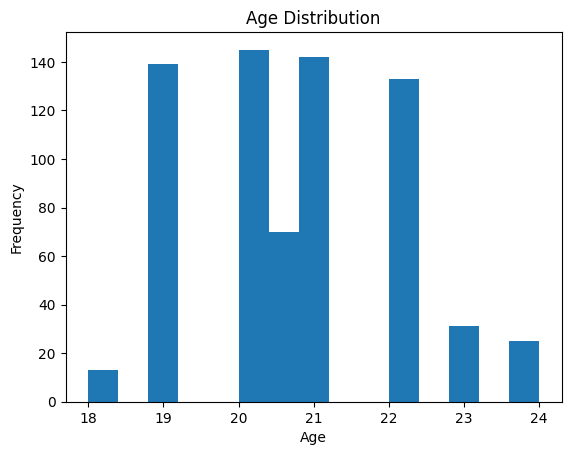

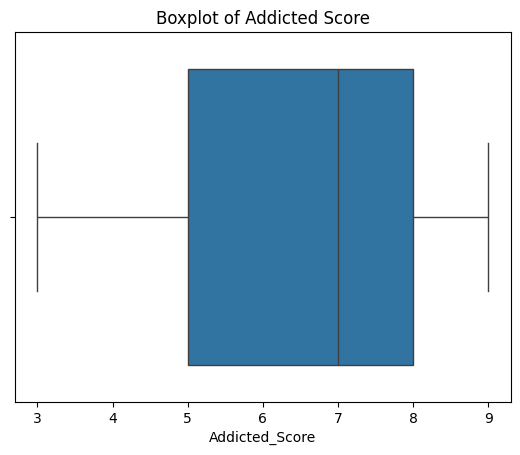

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram for Age
plt.hist(df['Age'], bins=15)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()

# Boxplot for Addicted_Score
sns.boxplot(x=df['Addicted_Score'])
plt.title('Boxplot of Addicted Score')
plt.show()


Visual representations help identify trends and spread of data.

Histograms show frequency distribution of values.
Boxplots help detect spread and potential outliers.


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Apply Min-Max Normalization
scaler = MinMaxScaler()
df[numeric_df.columns] = scaler.fit_transform(df[numeric_df.columns])

df.head()


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score,Age_Group,Addiction_Level
0,0.000000,0.166667,Female,Undergraduate,Bangladesh,0.542373,Instagram,Yes,0.436364,0.50,In Relationship,0.6,0.573383,Young Adult,High
1,0.001420,0.666667,Male,Graduate,India,0.016949,Twitter,No,0.505536,1.00,Single,0.0,0.000000,Young Adult,Low
2,0.002841,0.333333,Female,Undergraduate,USA,0.677966,TikTok,Yes,0.163636,0.25,Complicated,0.8,1.000000,Young Adult,High
3,0.004261,0.000000,Male,High School,UK,0.169492,YouTube,No,0.527273,0.75,Single,0.2,0.166667,Teen,Medium
4,0.005682,0.500000,Male,Graduate,Canada,0.423729,Facebook,Yes,0.345455,0.50,In Relationship,0.4,0.666667,Young Adult,High


Min–Max normalization scaled numerical attributes between 0 and 1.

This prevents attributes with large ranges from dominating analysis.
Normalized data improves algorithm performance.


In [ ]:
from sklearn.preprocessing import StandardScaler

# Apply Standard Scaler
std_scaler = StandardScaler()
df[numeric_df.columns] = std_scaler.fit_transform(df[numeric_df.columns])

df.head()


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score,Age_Group,Addiction_Level
0,-1.814753,-1.269913,Female,Undergraduate,Bangladesh,0.246623,Instagram,Yes,-0.376366,-0.230918,In Relationship,0.165992,0.007820,Young Adult,High
1,-1.809595,0.979712,Male,Graduate,India,-2.357148,Twitter,No,-0.017414,1.650299,Single,-3.045748,-2.238963,Young Adult,Low
2,-1.804438,-0.520038,Female,Undergraduate,USA,0.918564,TikTok,Yes,-1.791614,-1.171527,Complicated,1.236572,1.679505,Young Adult,High
3,-1.799281,-2.019788,Male,High School,UK,-1.601214,YouTube,No,0.095384,0.709691,Single,-1.975168,-1.585885,Teen,Medium
4,-1.794123,0.229837,Male,Graduate,Canada,-0.341325,Facebook,Yes,-0.848115,-0.230918,In Relationship,-0.904588,0.373349,Young Adult,High


Association Rule Mining discovers relationships between variables in large datasets.

It identifies frequent patterns using measures like support, confidence, and lift.
This technique is widely used for behavior and pattern analysis.


In [ ]:
# Correct Boolean conversion based on actual values
assoc_df = df.copy()

assoc_df['High_Addiction'] = assoc_df['Addicted_Score'] > df['Addicted_Score'].mean()
assoc_df['Low_Sleep'] = assoc_df['Sleep_Hours_Per_Night'] < df['Sleep_Hours_Per_Night'].mean()

# Convert academic performance impact to Boolean
assoc_df['Academic_Affected'] = assoc_df['Affects_Academic_Performance'].astype(str).str.lower().isin(['yes', 'true', '1'])

assoc_df = assoc_df[['High_Addiction', 'Low_Sleep', 'Academic_Affected']]

assoc_df.head(10)


,High_Addiction,Low_Sleep,Academic_Affected
0,True,True,True
1,False,True,False
2,True,True,True
3,False,False,False
4,True,True,True
5,True,True,True
7,True,True,True
8,False,True,False
9,False,False,False
10,True,True,True


In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

# Apply Apriori algorithm
frequent_itemsets = apriori(assoc_df, min_support=0.2, use_colnames=True)

# Generate association rules
apriori_rules = association_rules(frequent_itemsets,
                                  metric="confidence",
                                  min_threshold=0.6)

apriori_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,support,confidence,lift
0,(Low_Sleep),(High_Addiction),0.458453,0.906516,1.517381
1,(High_Addiction),(Low_Sleep),0.458453,0.767386,1.517381
2,(Academic_Affected),(High_Addiction),0.577364,0.901566,1.509096
3,(High_Addiction),(Academic_Affected),0.577364,0.966427,1.509096
4,(Academic_Affected),(Low_Sleep),0.467049,0.729306,1.442085
5,(Low_Sleep),(Academic_Affected),0.467049,0.923513,1.442085
6,"(Academic_Affected, Low_Sleep)",(High_Addiction),0.458453,0.981595,1.643054
7,"(Academic_Affected, High_Addiction)",(Low_Sleep),0.458453,0.794045,1.570094
8,"(High_Addiction, Low_Sleep)",(Academic_Affected),0.458453,1.000000,1.561521
9,(Academic_Affected),"(High_Addiction, Low_Sleep)",0.458453,0.715884,1.561521


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Apriori successfully generated association rules from the dataset.

Rules with high confidence and lift indicate strong relationships.
These patterns reveal behavioral dependencies in social media usage.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

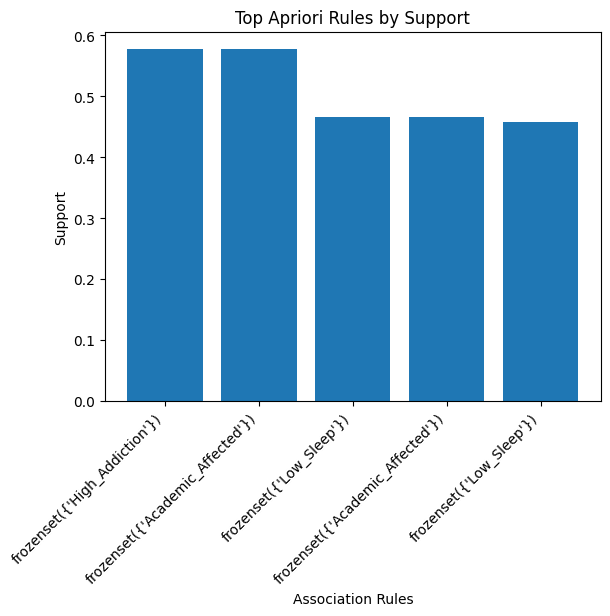

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import matplotlib.pyplot as plt

# Select top 5 rules by support
top_rules = apriori_rules.sort_values(by='support', ascending=False).head(5)

plt.bar(range(len(top_rules)), top_rules['support'])
plt.xticks(range(len(top_rules)), top_rules['antecedents'].astype(str), rotation=45, ha='right')
plt.xlabel('Association Rules')
plt.ylabel('Support')
plt.title('Top Apriori Rules by Support')
plt.show()


In [ ]:
from mlxtend.frequent_patterns import fpgrowth

# Apply FP-Growth algorithm
fp_itemsets = fpgrowth(assoc_df, min_support=0.2, use_colnames=True)

# Generate association rules
fp_rules = association_rules(fp_itemsets,
                             metric="confidence",
                             min_threshold=0.6)

fp_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,support,confidence,lift
0,(Academic_Affected),(High_Addiction),0.577364,0.901566,1.509096
1,(High_Addiction),(Academic_Affected),0.577364,0.966427,1.509096
2,(Academic_Affected),(Low_Sleep),0.467049,0.729306,1.442085
3,(Low_Sleep),(Academic_Affected),0.467049,0.923513,1.442085
4,(Low_Sleep),(High_Addiction),0.458453,0.906516,1.517381
5,(High_Addiction),(Low_Sleep),0.458453,0.767386,1.517381
6,"(Academic_Affected, Low_Sleep)",(High_Addiction),0.458453,0.981595,1.643054
7,"(Academic_Affected, High_Addiction)",(Low_Sleep),0.458453,0.794045,1.570094
8,"(High_Addiction, Low_Sleep)",(Academic_Affected),0.458453,1.000000,1.561521
9,(Academic_Affected),"(High_Addiction, Low_Sleep)",0.458453,0.715884,1.561521


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

FP-Growth generated similar rules with improved efficiency.

It reduced computation compared to Apriori.
This demonstrates algorithmic optimization in association mining.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

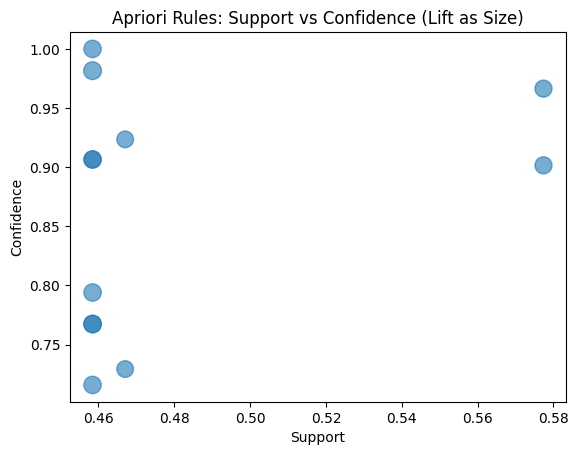

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
plt.scatter(apriori_rules['support'],
            apriori_rules['confidence'],
            s=apriori_rules['lift'] * 100,
            alpha=0.6)

plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Apriori Rules: Support vs Confidence (Lift as Size)')
plt.show()


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

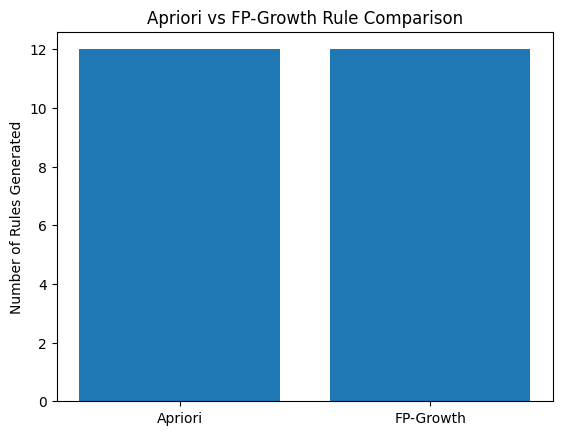

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
algo_names = ['Apriori', 'FP-Growth']
rule_counts = [len(apriori_rules), len(fp_rules)]

plt.bar(algo_names, rule_counts)
plt.ylabel('Number of Rules Generated')
plt.title('Apriori vs FP-Growth Rule Comparison')
plt.show()


In [ ]:
apriori_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head()


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,support,confidence,lift
0,(Low_Sleep),(High_Addiction),0.458453,0.906516,1.517381
1,(High_Addiction),(Low_Sleep),0.458453,0.767386,1.517381
2,(Academic_Affected),(High_Addiction),0.577364,0.901566,1.509096
3,(High_Addiction),(Academic_Affected),0.577364,0.966427,1.509096
4,(Academic_Affected),(Low_Sleep),0.467049,0.729306,1.442085


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Quantitative association rules involve numerical conditions.

They identify relationships based on value ranges.
Such rules provide deeper insights than Boolean rules.


In [ ]:
# Create Academic_Affected in df (Boolean)
df['Academic_Affected'] = (
    df['Affects_Academic_Performance']
    .astype(str)
    .str.lower()
    .isin(['yes', 'true', '1'])
)

# Quantitative condition
df['High_Addiction_Q'] = df['Addicted_Score'] > df['Addicted_Score'].mean()

# Prepare dataset
quant_df = df[['High_Addiction_Q', 'Academic_Affected']]

quant_df.head()


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,High_Addiction_Q,Academic_Affected
0,True,True
1,False,False
2,True,True
3,False,False
4,True,True


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Classification is a supervised learning technique used to predict class labels.

In this project, engagement-related behavior is predicted using classification models.
Decision Tree and Naive Bayes algorithms are applied.


In [ ]:
from sklearn.model_selection import train_test_split

# Features and target
X = df[['Addicted_Score', 'Sleep_Hours_Per_Night', 'Avg_Daily_Usage_Hours']]
y = df['Academic_Affected']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_train.shape, X_test.shape


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

((488, 3), (210, 3))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

The Decision Tree algorithm uses a tree-like structure for decision making.

It splits data based on feature values to form classification rules.
Decision Trees are easy to interpret and visualize.


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
dt_pred = dt_model.predict(X_test)
